In [3]:
import torch
print(torch.cuda.is_available())  # should print True
print(torch.cuda.get_device_name(0))  # should print RTX 3060 Ti
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import stable_retro
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym

True
NVIDIA GeForce RTX 3060 Ti


#### Mario Environment and Rewards

In [4]:
def compute_reward(prev_info, curr_info, done):
    reward = 0.0

    # --- Progress ---
    curr_pos = curr_info.get('screen', 0) * 256 + curr_info['x']
    prev_pos = prev_info.get('screen', 0) * 256 + prev_info['x']
    delta_x = curr_pos - prev_pos
    if 0 < delta_x < 200:
        reward += delta_x * 0.01

    # --- Milestones ---
    if curr_info.get('midpoint_flag', 0) > prev_info.get('midpoint_flag', 0):
        reward += 5.0
    # if curr_info.get('FINISH', 0) > prev_info.get('FINISH', 0):
    #     reward += 500.0

    # --- Powerups ---
    if curr_info.get('powerup_status', 0) > prev_info.get('powerup_status', 0):
        reward += 1.0

    # --- Penalties ---
    if done:
        reward -= 5.0
    if curr_pos < prev_pos:
        reward -= 0.05

    # print(f"delta_x: {delta_x}, reward: {reward}")
    return reward

In [5]:
ACTIONS = [
    [0,0,0,0,0,0,0,0,0,0,0,0],  # nothing
    [0,0,0,0,0,0,0,1,0,0,0,0],  # right
    [0,0,0,0,0,0,0,1,1,0,0,0],  # right + A (jump)
    [0,0,0,0,0,0,0,1,0,1,0,0],  # right + Y (run)
    [0,0,0,0,0,0,0,1,1,1,0,0],  # right + A + Y (run jump)
    [0,0,0,0,0,0,0,0,1,0,0,0],  # A (jump)
]

class SMWEnv(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.actions = ACTIONS
        # Override the observation space to match your tuple state
        self.observation_space = gym.spaces.Box(
            low=np.array([0, 0, 0, 0, 0], dtype=np.float32),
            high=np.array([255, 9999, 3, 1, 1], dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = gym.spaces.Discrete(len(ACTIONS))  # now 6 instead of 4096
        self.prev_info = {}

    def reset(self, **kwargs):
        _, info = self.env.reset(**kwargs)
        self.prev_info = {'x': 0, 'screen': 0, 'powerup_status': 0, 'riding_yoshi': 0, 'midpoint_flag': 0, 'lives': 4, 'score': 0, 'coins': 0}
        obs = self.get_obs(info)
        return obs, info

    def step(self, action):
        actual_action = self.actions[action]
        # print(f"action idx: {action}, actual: {actual_action}")
        _, _, terminated, truncated, info = self.env.step(actual_action)
        obs = self.get_obs(info)
        reward = compute_reward(self.prev_info, info, terminated or truncated)
        if info.get('lives', 4) < self.prev_info.get('lives', 4):
            terminated = True
        self.prev_info = info
        print(info.get('x', 0))
        return obs, reward, terminated, truncated, info

    def get_obs(self, info):
        return np.array([
            info.get('screen', 0) / 255.0,
            info.get('x', 0) / 255.0,
            info.get('powerup_status', 0) / 3.0,
            info.get('riding_yoshi', 0),
            info.get('midpoint_flag', 0),
        ], dtype=np.float32)

#### Actor and Critic

In [6]:
class Actor(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.fc1 = nn.Linear(obs_dim, 64)   # 5 inputs → 64 neurons
        self.fc2 = nn.Linear(64, 64)        # 64 → 64
        self.fc3 = nn.Linear(64, action_dim) # 64 → one output per action

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        probs = F.softmax(self.fc3(x), dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob, dist

class Critic(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.obs_dim = obs_dim
        self.fc1 = nn.Linear(obs_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

#### PPO Algorithm

In [7]:
try:
    base_env.close()
except:
    pass

In [8]:
base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode='human')
env = SMWEnv(base_env)

total_rewards = []
steps_per_ep  = []
max_x_per_ep  = []
actor_losses  = []
critic_losses = []

In [9]:
class SMW_PPO:
    def __init__(self, env, obs_dim, action_dim, theta, n_workers, epsilon = 0.2, alpha = 0.95, gamma=0.99, num_steps=8192):
        self.env = env
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.num_steps = num_steps
        self.n_workers = n_workers
        self.num_eps = 500

        #create array for collecting trajectories
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []
        self.theta = theta

        self.state, _ = self.env.reset()

        #call in my actor and critic class and optimize them
        self.actor = Actor(obs_dim=5, action_dim=self.env.action_space.n)
        self.critic = Critic(obs_dim=5)
        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=1e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

        self.policy = []
        
    def collect_trajectories(self):
        #iterate through my steps typically PPO is 2048
        # for _ in range(self.num_steps):
        done = False
        while not done:
            #set up my actor and critic
            action, log_prob, _ = self.actor(torch.tensor(self.state, dtype=torch.float32))
            action_idx = action.item()
            # print(action_idx)
            next_state, reward, terminated, truncated, info = self.env.step(action_idx)
            done = terminated or truncated
            value = self.critic(torch.tensor(self.state, dtype=torch.float32))


            #grab all my trajectories and append them
            self.states.append(self.state)
            self.actions.append(action_idx)
            self.rewards.append(reward)
            self.log_probs.append(log_prob)
            self.values.append(value)
            self.dones.append(done)

            # reset if episode ended
            if done:
                self.state, _ = self.env.reset()
            else:
                self.state = next_state

        #return my set of trajectories
        return self.states, self.actions, self.rewards, self.log_probs, self.values, self.dones

    def r_to_go(self):
        Rt = []
        discounted_sum = 0
        
        #grab all rewards and dones and add them into my discounted sum
        for reward, done in zip(reversed(self.rewards), reversed(self.dones)):
            if done:
                discounted_sum = 0

            discounted_sum = reward + self.gamma * discounted_sum
            Rt.insert(0, discounted_sum)

        return Rt

    def advantage_est(self):
        V = torch.stack(self.values).squeeze().detach()
        T = len(self.rewards)
        advantages = []
        next_gae = 0

        for t in reversed(range(T)):
            if self.dones[t]:
                next_value = 0
                next_gae = 0
            else:
                next_value = V[t+1].item() if t+1 < T else 0

            delta = self.rewards[t] + self.gamma * next_value - V[t].item()
            gae = delta + self.gamma * self.alpha * next_gae
            next_gae = gae
            advantages.insert(0, torch.tensor(gae, dtype=torch.float32))

        advantages = torch.stack(advantages)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return advantages

    # def advantage_est(self):
    #     #take a generic advantage estimation
    #     advantages = Rt - V.detach()
    #     advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    #     return advantages
    
    def update(self):
        states_t = torch.tensor(np.array(self.states), dtype=torch.float32)
        old_logs = torch.stack(self.log_probs).detach()
        advantages = self.advantage_est().detach()
        returns = torch.tensor(self.r_to_go(), dtype=torch.float32)

        for _ in range(3):
            _, new_log_probs, dist = self.actor(states_t)
            new_values = self.critic(states_t).squeeze()

            ratio = torch.exp(new_log_probs - old_logs)

            unclipped = ratio * advantages
            clipped = torch.clamp(ratio, 1-self.epsilon, 1+self.epsilon) * advantages

            entropy = dist.entropy().mean()
            actor_loss = -torch.mean(torch.min(unclipped, clipped)) - 0.04 * entropy
            critic_loss = nn.MSELoss()(new_values, returns)

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            self.actor_optimizer.step()

            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
            self.critic_optimizer.step()

        return actor_loss.item(), critic_loss.item()
        
    def clear_buffer(self):
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []

    def rollout(self):
        for ep in range(self.num_eps):
            self.collect_trajectories()

            total_rewards.append(sum(self.rewards))
            steps_per_ep.append(len(self.rewards))
            max_x_per_ep.append(max(int(s[0] * 255) * 256 + int(s[1] * 255) for s in self.states))
            actor_loss, critic_loss = self.update()
            actor_losses.append(actor_loss)
            critic_losses.append(critic_loss)
            if ep % 50 == 0:
                torch.save(self.actor.state_dict(), f'actor_ep{ep}.pth')
                torch.save(self.critic.state_dict(), f'critic_ep{ep}.pth')

            self.clear_buffer()
            print(f"Episode {ep+1}/{self.num_eps} | Reward: {total_rewards[-1]:.2f} | Max X: {max_x_per_ep[-1]}")

#### Run the agent

In [10]:
agent = SMW_PPO(env=env, obs_dim=5, action_dim=env.action_space.n, theta=None, n_workers=1)
agent.rollout()

16
16
16
16
16
16
16
16
17
17
17
18
18
19
19
20
21
22
23
24
25
26
27
28
29
30
32
33
34
36
37
39
40
41
42
44
45
46
47
48
49
51
52
53
54
56
57
58
59
61
62
63
65
66
67
68
70
71
72
74
75
77
78
80
81
82
84
85
86
87
89
90
91
93
94
95
97
98
99
101
102
103
105
106
107
108
110
111
112
114
115
116
117
118
120
121
122
124
125
126
127
129
130
131
132
134
135
136
138
139
141
142
144
146
147
149
150
152
153
155
156
158
159
160
162
163
165
166
167
169
170
172
173
175
176
178
179
181
182
184
186
187
189
191
192
194
195
197
198
199
201
203
204
206
207
209
210
211
213
214
216
217
219
220
222
223
225
226
228
229
231
233
234
236
237
239
241
242
244
245
247
248
250
251
253
255
1
2
4
6
8
10
12
13
15
17
19
21
23
26
28
30
32
34
36
38
40
42
44
46
47
49
51
53
55
56
58
60
62
64
66
68
70
72
74
76
78
80
82
84
86
88
90
92
94
96
98
100
102
104
106
108
110
112
114
116
118
120
122
124
127
129
131
133
136
138
140
142
144
146
148
151
153
155
157
160
162
164
166
168
171
173
175
178
180
182
184
186
188
190
193
195
197
200

KeyboardInterrupt: 

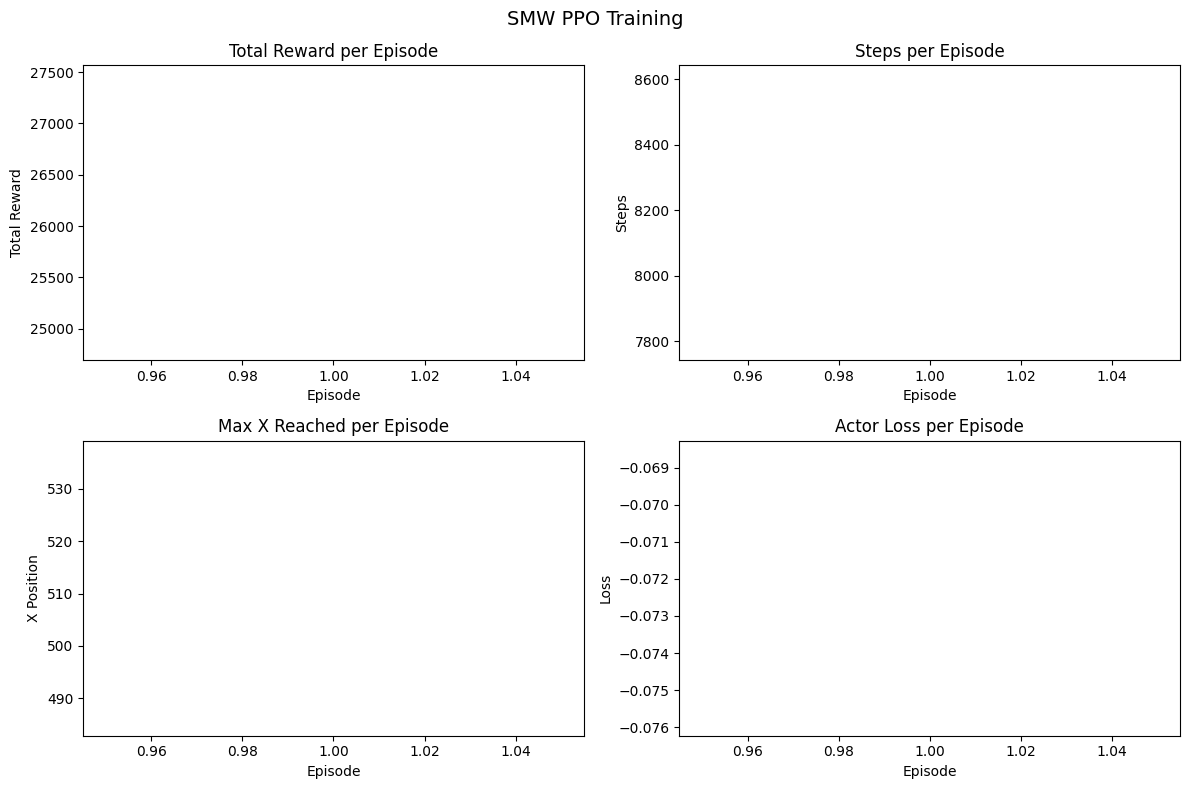

In [12]:
num_eps = len(total_rewards)
eps = range(1, num_eps + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('SMW PPO Training', fontsize=14)

axes[0, 0].plot(eps, total_rewards)
axes[0, 0].set_title('Total Reward per Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')

axes[0, 1].plot(eps, steps_per_ep)
axes[0, 1].set_title('Steps per Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps')

axes[1, 0].plot(eps, max_x_per_ep)
axes[1, 0].set_title('Max X Reached per Episode')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('X Position')

axes[1, 1].plot(eps, actor_losses)
axes[1, 1].set_title('Actor Loss per Episode')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('6actions_10ep_results.png')
plt.show()

In [13]:
# test a bunch of addresses around where x should be
import stable_retro

env = stable_retro.make(game='SuperMarioWorld-Snes-v0', render_mode='human')
env.reset()

for _ in range(100):
    action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  # hold right
    env.step(action)

ram = env.get_ram()
# print addresses in the range we care about
for addr in [0x00D1, 0x00D3, 0x0086, 0x00D4, 0x00B6, 0x00B8]:
    print(f"0x{addr:04X}: {ram[addr]}")
    print(0x7E0000 + 0x00D1)  # x
    print(0x7E0000 + 0x00D4)  # screen  

env.close()

RuntimeError: Cannot create multiple emulator instances per process, make sure to call env.close() on each environment before creating a new one